In [1]:
# notebooks/05_ab_test.ipynb
# Cell 1 - 라이브러리 및 DB 연결

import pandas as pd
import sqlite3
import numpy as np
from scipy import stats
import statsmodels.stats.power as smp
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = r'..\data\db\fintech.db'
conn = sqlite3.connect(DB_PATH)
print("DB 연결 완료")

DB 연결 완료


In [2]:
# Cell 2 - 가설 설정

print("=" * 55)
print("A/B 테스트 설계")
print("=" * 55)
print("""
[배경]
AARRR 퍼널 분석 결과, 첫 거래 후 30일 내 재거래
전환율(Activation)이 66%로 확인됨.
Activation된 유저의 97.5%가 장기 유저로 전환되므로
초기 30일이 핵심 분기점임.

[실험 설계]
- 대조군(Control): 아무 개입 없음 (현재 상태)
- 실험군(Treatment): 첫 거래 후 7일·14일·30일
  시점에 맞춤 리마인드 알림 발송

[가설]
- 귀무가설 H₀: 알림이 30일 내 재거래 전환율에
  영향을 미치지 않는다
  (p_control = p_treatment)

- 대립가설 H₁: 알림을 받은 실험군의 30일 내
  재거래 전환율이 대조군보다 높다
  (p_treatment > p_control)

[검정 방식]
- 단측 검정 (one-tailed)
- 이유: 알림이 전환율을 높일 것이라는
  방향성이 명확하기 때문

[KPI]
- 기준 전환율 (p_control): 66.0%
- 목표 전환율 (p_treatment): 75.0%
- 최소 감지 효과 (MDE): +9%p
""")

A/B 테스트 설계

[배경]
AARRR 퍼널 분석 결과, 첫 거래 후 30일 내 재거래
전환율(Activation)이 66%로 확인됨.
Activation된 유저의 97.5%가 장기 유저로 전환되므로
초기 30일이 핵심 분기점임.

[실험 설계]
- 대조군(Control): 아무 개입 없음 (현재 상태)
- 실험군(Treatment): 첫 거래 후 7일·14일·30일
  시점에 맞춤 리마인드 알림 발송

[가설]
- 귀무가설 H₀: 알림이 30일 내 재거래 전환율에
  영향을 미치지 않는다
  (p_control = p_treatment)

- 대립가설 H₁: 알림을 받은 실험군의 30일 내
  재거래 전환율이 대조군보다 높다
  (p_treatment > p_control)

[검정 방식]
- 단측 검정 (one-tailed)
- 이유: 알림이 전환율을 높일 것이라는
  방향성이 명확하기 때문

[KPI]
- 기준 전환율 (p_control): 66.0%
- 목표 전환율 (p_treatment): 75.0%
- 최소 감지 효과 (MDE): +9%p



In [3]:
# Cell 3 - Power Analysis (표본 크기 계산)

# 파라미터 설정
p_control = 0.66      # 현재 Activation 전환율
p_treatment = 0.75    # 목표 전환율 (MDE = 9%p)
alpha = 0.05          # 유의수준
power = 0.80          # 검정력 (1 - β)

# 효과 크기 계산 (Cohen's h)
effect_size = 2 * np.arcsin(np.sqrt(p_treatment)) - \
              2 * np.arcsin(np.sqrt(p_control))

print(f"효과 크기 (Cohen's h): {effect_size:.4f}")

# 표본 크기 계산
analysis = smp.NormalIndPower()
n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='larger'  # 단측 검정
)

n = int(np.ceil(n))
print(f"\n=== Power Analysis 결과 ===")
print(f"유의수준 (α): {alpha}")
print(f"검정력 (1-β): {power}")
print(f"기준 전환율: {p_control:.1%}")
print(f"목표 전환율: {p_treatment:.1%}")
print(f"MDE: +{(p_treatment-p_control):.1%}")
print(f"\n그룹당 필요 표본 수: {n:,}명")
print(f"전체 필요 표본 수: {n*2:,}명")
print(f"\n현재 분석 대상 유저 수: 1,657명")
print(f"→ 충분 여부: {'✓ 충분' if 1657 >= n*2 else '✗ 부족'}")

효과 크기 (Cohen's h): 0.1979

=== Power Analysis 결과 ===
유의수준 (α): 0.05
검정력 (1-β): 0.8
기준 전환율: 66.0%
목표 전환율: 75.0%
MDE: +9.0%

그룹당 필요 표본 수: 316명
전체 필요 표본 수: 632명

현재 분석 대상 유저 수: 1,657명
→ 충분 여부: ✓ 충분


In [5]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

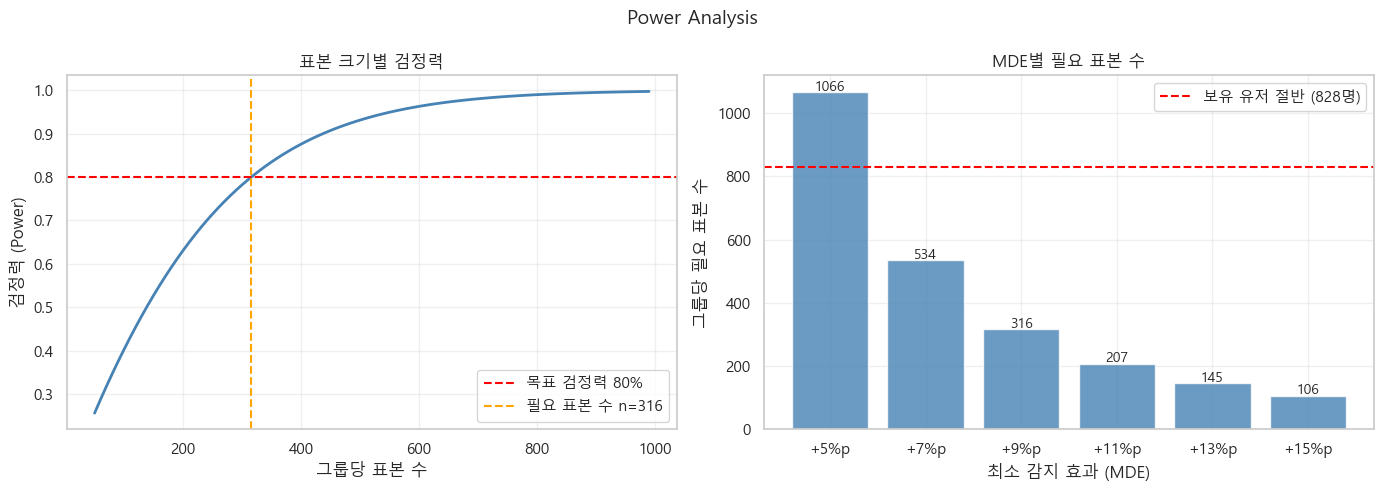

In [6]:
# Cell 4 - Power Curve 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Power Analysis', fontsize=14)

# 표본 크기별 검정력 변화
sample_sizes = range(50, 1000, 10)
powers = [smp.NormalIndPower().solve_power(
    effect_size=effect_size,
    nobs1=n,
    alpha=alpha,
    alternative='larger'
) for n in sample_sizes]

axes[0].plot(sample_sizes, powers, color='steelblue', linewidth=2)
axes[0].axhline(y=0.80, color='red', linestyle='--', label='목표 검정력 80%')
axes[0].axvline(x=n, color='orange', linestyle='--',
                label=f'필요 표본 수 n={n}')
axes[0].set_title('표본 크기별 검정력')
axes[0].set_xlabel('그룹당 표본 수')
axes[0].set_ylabel('검정력 (Power)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MDE별 필요 표본 수
mde_list = [0.05, 0.07, 0.09, 0.11, 0.13, 0.15]
n_list = []
for mde in mde_list:
    p_t = p_control + mde
    es = 2 * np.arcsin(np.sqrt(p_t)) - \
         2 * np.arcsin(np.sqrt(p_control))
    n_mde = smp.NormalIndPower().solve_power(
        effect_size=es,
        alpha=alpha,
        power=power,
        alternative='larger'
    )
    n_list.append(int(np.ceil(n_mde)))

axes[1].bar([f'+{int(m*100)}%p' for m in mde_list],
            n_list, color='steelblue', alpha=0.8)
axes[1].axhline(y=1657//2, color='red', linestyle='--',
                label=f'보유 유저 절반 ({1657//2}명)')
for bar, n_val in zip(axes[1].patches, n_list):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{n_val}', ha='center', fontsize=10)
axes[1].set_title('MDE별 필요 표본 수')
axes[1].set_xlabel('최소 감지 효과 (MDE)')
axes[1].set_ylabel('그룹당 필요 표본 수')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'..\outputs\ab_power_analysis.png', dpi=150)
plt.show()

**Power Analysis 결과 해석**

- 그룹당 316명, 전체 632명이 필요한데 현재 보유 유저가 1,657명이라 충분함.

- Cohen's h = 0.1979는 작은 효과 크기(small effect). 0.2 미만이라 미묘한 차이를 감지하는 실험임. 그만큼 표본이 충분히 필요한데 우리는 충분함.

- MDE별 차트에서 보면 +5%p 개선을 감지하려면 1,066명이 필요해서 보유 유저(828명)로 부족함. +7%p는 534명으로 가능하고, +9%p부터는 316명으로 충분. 우리 목표 +9%p가 현실적인 수준임을 확인.

*효과가 클수록 적은 샘플로도 감지 가능*

- +5%p 차이 (66% vs 71%)

→ 차이가 작아서 노이즈에 묻힐 수 있음

→ 확실히 감지하려면 많은 샘플 필요 (1,066명)

- +15%p 차이 (66% vs 81%)

→ 차이가 커서 적은 샘플로도 명확히 보임

→ 적은 샘플로 충분 (106명)

> 효과 크기(Cohen's h)가 클수록 Signal이 강해지고, 같은 검정력(80%)을 달성하는 데 필요한 샘플이 줄어듬

*중요한 트레이드오프 존재*
- MDE를 크게 잡으면 샘플은 적게 필요하지만, "작은 효과"는 감지 못함. 실제로 알림이 +5%p 효과가 있어도 MDE를 +15%p로 잡으면 "유의미하지 않다"고 잘못 결론 내릴 수 있음.
- 그래서 MDE는 "비즈니스적으로 의미있는 최소 개선치"로 잡는 게 맞음. 우리가 +9%p로 잡은 것도 그 이유.



In [7]:
# Cell 5 - 실제 데이터 기반 시뮬레이션 준비
# 첫 거래 후 30일 내 재거래 여부 데이터 추출

activation_query = """
WITH first_tx AS (
    SELECT
        User,
        MIN(date_int) AS first_date,
        MIN(Year) AS first_year,
        MIN(Month) AS first_month,
        MIN(Day) AS first_day
    FROM clean_transactions
    GROUP BY User
),
second_tx AS (
    SELECT
        c.User,
        MIN(c.date_int) AS second_date
    FROM clean_transactions c
    JOIN first_tx f ON c.User = f.User
    WHERE c.date_int > f.first_date
    GROUP BY c.User
)
SELECT
    f.User,
    f.first_date,
    s.second_date,
    CASE
        WHEN s.second_date IS NULL THEN 0
        WHEN (s.second_date - f.first_date) <= 30 THEN 1
        ELSE 0
    END AS activated
FROM first_tx f
LEFT JOIN second_tx s ON f.User = s.User
"""

activation_df = pd.read_sql(activation_query, conn)
print(f"전체 유저: {len(activation_df):,}명")
print(f"Activated: {activation_df['activated'].sum():,}명")
print(f"실제 Activation율: {activation_df['activated'].mean():.4f} ({activation_df['activated'].mean()*100:.1f}%)")

전체 유저: 1,657명
Activated: 1,093명
실제 Activation율: 0.6596 (66.0%)


In [13]:
# Cell 6 앞에 추가 - rfm_df 다시 계산

rfm_query = """
WITH cohort_base AS (
    SELECT User, MIN(Year) AS cohort_year
    FROM clean_transactions
    GROUP BY User
),
filtered_cohort AS (
    SELECT User, cohort_year
    FROM cohort_base
    WHERE cohort_year >= 2002
)
SELECT
    c.User,
    (2019 - MAX(c.Year)) AS recency_years,
    ROUND(COUNT(*) * 1.0 /
        CASE WHEN (MAX(c.Year) - MIN(c.Year)) = 0 THEN 1
        ELSE (MAX(c.Year) - MIN(c.Year)) END, 0) AS frequency,
    ROUND(SUM(CASE WHEN c.Amount > 0 THEN c.Amount ELSE 0 END) /
        CASE WHEN (MAX(c.Year) - MIN(c.Year)) = 0 THEN 1
        ELSE (MAX(c.Year) - MIN(c.Year)) END, 0) AS monetary
FROM clean_transactions c
JOIN filtered_cohort fc ON c.User = fc.User
GROUP BY c.User
"""

rfm_df = pd.read_sql(rfm_query, conn)

# R 점수
def recency_score(years):
    if years == 0:    return 5
    elif years <= 2:  return 4
    elif years <= 5:  return 3
    elif years <= 9:  return 2
    else:             return 1

rfm_df['R'] = rfm_df['recency_years'].apply(recency_score)
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)
rfm_df['M'] = pd.qcut(rfm_df['monetary'].rank(method='first'),
                       q=5, labels=[1,2,3,4,5]).astype(int)
rfm_df['RFM_score'] = rfm_df['R'] + rfm_df['F'] + rfm_df['M']

def classify_rfm(row):
    score = row['RFM_score']
    r = row['R']
    f = row['F']
    m = row['M']
    if score >= 13:   return 'VIP'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential'
    elif r <= 2 and (f >= 3 or m >= 3): return 'At Risk'
    else:             return 'Dormant'

rfm_df['segment'] = rfm_df.apply(classify_rfm, axis=1)
print(f"RFM 완료: {len(rfm_df):,}명")
print(rfm_df['segment'].value_counts())

RFM 완료: 1,337명
segment
Loyal        449
Potential    434
VIP          421
Dormant       31
At Risk        2
Name: count, dtype: int64


In [14]:
# Cell 6 수정 - RFM 세그먼트 기반 시뮬레이션

np.random.seed(42)

# activation_df에 RFM 세그먼트 붙이기
activation_rfm = activation_df.merge(
    rfm_df[['User', 'segment']], on='User', how='left'
)
activation_rfm['segment'] = activation_rfm['segment'].fillna('Potential')

print("=== 세그먼트별 현재 Activation 현황 ===")
seg_activation = activation_rfm.groupby('segment').agg(
    user_count=('User', 'count'),
    activated=('activated', 'sum'),
    activation_rate=('activated', 'mean')
).round(3)
print(seg_activation)

=== 세그먼트별 현재 Activation 현황 ===
           user_count  activated  activation_rate
segment                                          
At Risk             2          0            0.000
Dormant            31         26            0.839
Loyal             449        313            0.697
Potential         754        489            0.649
VIP               421        265            0.629


In [15]:
# Cell 7 - 세그먼트별 알림 전환 확률 설정 및 시뮬레이션

# 세그먼트별 알림으로 인한 추가 전환 확률 설정
# (미전환 유저 중 알림을 받았을 때 전환할 확률)
nudge_prob = {
    'VIP':       0.10,   # 이미 활성화 잘 됨 → 효과 낮음
    'Loyal':     0.20,   # 중간 효과
    'Potential': 0.40,   # 습관 미형성 → 효과 가장 높음
    'At Risk':   0.05,   # 이탈 성향 강함 → 효과 거의 없음
    'Dormant':   0.05    # 거의 없음
}

# 전체 유저 중 632명 샘플링
n_per_group = 316
total_sample = activation_rfm.sample(n=n_per_group * 2, random_state=42)

control = total_sample.iloc[:n_per_group].copy()
treatment = total_sample.iloc[n_per_group:].copy()

# 대조군: 실제 데이터 그대로
control_rate = control['activated'].mean()

# 실험군: 세그먼트별 전환 확률 적용
treatment_sim = treatment.copy()

for idx, row in treatment_sim.iterrows():
    if row['activated'] == 0:  # 미전환 유저만 대상
        seg = row['segment']
        prob = nudge_prob.get(seg, 0.10)
        # 해당 확률로 전환 여부 결정
        if np.random.random() < prob:
            treatment_sim.loc[idx, 'activated'] = 1

treatment_rate = treatment_sim['activated'].mean()

print("=== 세그먼트별 알림 전환 확률 ===")
for seg, prob in nudge_prob.items():
    print(f"  {seg:12s}: +{prob:.0%}")

print(f"\n=== 그룹별 결과 ===")
print(f"대조군 (n={n_per_group}): {int(control['activated'].sum())}명 활성화 → {control_rate:.4f} ({control_rate*100:.1f}%)")
print(f"실험군 (n={n_per_group}): {int(treatment_sim['activated'].sum())}명 활성화 → {treatment_rate:.4f} ({treatment_rate*100:.1f}%)")
print(f"전환율 차이: +{(treatment_rate - control_rate)*100:.1f}%p")

# 세그먼트별 효과 확인
print("\n=== 세그먼트별 개선 효과 ===")
for seg in nudge_prob.keys():
    ctrl_seg = control[control['segment'] == seg]['activated'].mean()
    treat_seg = treatment_sim[treatment_sim['segment'] == seg]['activated'].mean()
    n_seg = len(treatment_sim[treatment_sim['segment'] == seg])
    if n_seg > 0:
        print(f"  {seg:12s}: {ctrl_seg:.1%} → {treat_seg:.1%} (+{(treat_seg-ctrl_seg)*100:.1f}%p, n={n_seg})")

=== 세그먼트별 알림 전환 확률 ===
  VIP         : +10%
  Loyal       : +20%
  Potential   : +40%
  At Risk     : +5%
  Dormant     : +5%

=== 그룹별 결과 ===
대조군 (n=316): 214명 활성화 → 0.6772 (67.7%)
실험군 (n=316): 250명 활성화 → 0.7911 (79.1%)
전환율 차이: +11.4%p

=== 세그먼트별 개선 효과 ===
  VIP         : 60.2% → 73.1% (+12.8%p, n=78)
  Loyal       : 75.0% → 77.1% (+2.1%p, n=83)
  Potential   : 68.1% → 83.0% (+14.9%p, n=147)
  At Risk     : nan% → 0.0% (+nan%p, n=1)
  Dormant     : 75.0% → 100.0% (+25.0%p, n=7)


In [16]:
# Cell 8 - z-test 통계 검정

from statsmodels.stats.proportion import proportions_ztest, proportion_confint

count = np.array([
    treatment_sim['activated'].sum(),
    control['activated'].sum()
])
nobs = np.array([n_per_group, n_per_group])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("=== 통계 검정 결과 (단측 z-test) ===")
print(f"Z 통계량: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"유의수준 α: 0.05")
print(f"\n결론: {'✓ 귀무가설 기각 (통계적으로 유의미)' if p_value < 0.05 else '✗ 귀무가설 채택 (유의미하지 않음)'}")

ci_control = proportion_confint(
    control['activated'].sum(), n_per_group, alpha=0.05, method='normal')
ci_treatment = proportion_confint(
    treatment_sim['activated'].sum(), n_per_group, alpha=0.05, method='normal')

print(f"\n대조군 95% 신뢰구간: [{ci_control[0]:.3f}, {ci_control[1]:.3f}]")
print(f"실험군 95% 신뢰구간: [{ci_treatment[0]:.3f}, {ci_treatment[1]:.3f}]")

=== 통계 검정 결과 (단측 z-test) ===
Z 통계량: 3.2415
p-value: 0.0006
유의수준 α: 0.05

결론: ✓ 귀무가설 기각 (통계적으로 유의미)

대조군 95% 신뢰구간: [0.626, 0.729]
실험군 95% 신뢰구간: [0.746, 0.836]


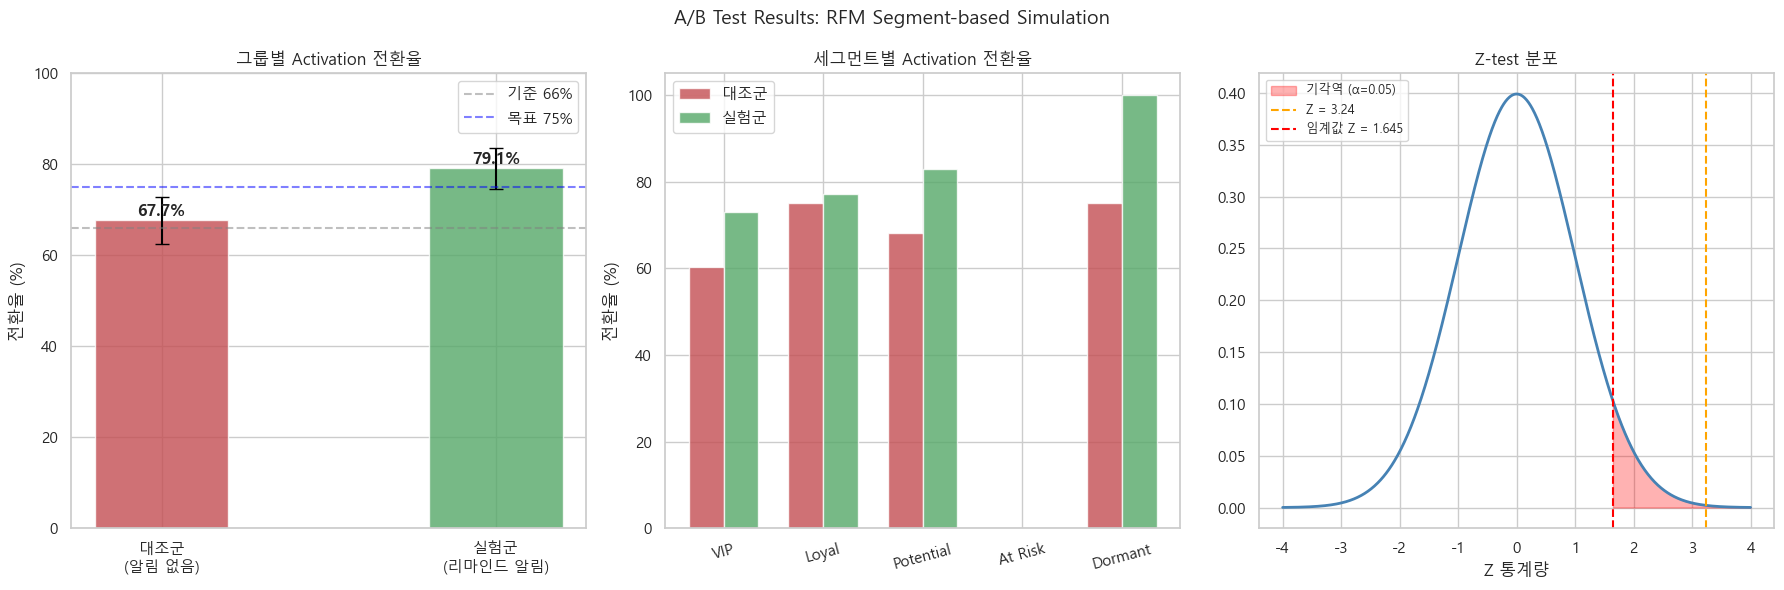

In [17]:
# Cell 9 - 결과 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('A/B Test Results: RFM Segment-based Simulation', fontsize=14)

# 전환율 비교
groups = ['대조군\n(알림 없음)', '실험군\n(리마인드 알림)']
rates = [control_rate, treatment_rate]
colors = ['#C44E52', '#55A868']

bars = axes[0].bar(groups, [r*100 for r in rates],
                   color=colors, width=0.4, alpha=0.8)
for bar, rate, ci in zip(bars, rates, [ci_control, ci_treatment]):
    axes[0].errorbar(
        bar.get_x() + bar.get_width()/2,
        rate*100,
        yerr=[[(rate - ci[0])*100], [(ci[1] - rate)*100]],
        fmt='none', color='black', capsize=5
    )
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{rate*100:.1f}%',
                ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('그룹별 Activation 전환율')
axes[0].set_ylabel('전환율 (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=66, color='gray', linestyle='--',
                alpha=0.5, label='기준 66%')
axes[0].axhline(y=75, color='blue', linestyle='--',
                alpha=0.5, label='목표 75%')
axes[0].legend()

# 세그먼트별 효과
seg_results = []
for seg in nudge_prob.keys():
    ctrl = control[control['segment'] == seg]['activated'].mean()
    treat = treatment_sim[treatment_sim['segment'] == seg]['activated'].mean()
    n = len(treatment_sim[treatment_sim['segment'] == seg])
    if n > 0:
        seg_results.append({
            'segment': seg,
            'control': ctrl * 100,
            'treatment': treat * 100,
            'improvement': (treat - ctrl) * 100,
            'n': n
        })

seg_df = pd.DataFrame(seg_results)
x = np.arange(len(seg_df))
width = 0.35

axes[1].bar(x - width/2, seg_df['control'],
            width, label='대조군', color='#C44E52', alpha=0.8)
axes[1].bar(x + width/2, seg_df['treatment'],
            width, label='실험군', color='#55A868', alpha=0.8)
axes[1].set_title('세그먼트별 Activation 전환율')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_df['segment'], rotation=15)
axes[1].set_ylabel('전환율 (%)')
axes[1].legend()

# Z-test 분포
x_dist = np.linspace(-4, 4, 1000)
y_dist = stats.norm.pdf(x_dist)
axes[2].plot(x_dist, y_dist, color='steelblue', linewidth=2)
axes[2].fill_between(x_dist, y_dist,
                     where=(x_dist >= stats.norm.ppf(0.95)),
                     color='red', alpha=0.3, label='기각역 (α=0.05)')
axes[2].axvline(x=z_stat, color='orange', linestyle='--',
                label=f'Z = {z_stat:.2f}')
axes[2].axvline(x=stats.norm.ppf(0.95), color='red',
                linestyle='--', label='임계값 Z = 1.645')
axes[2].set_title('Z-test 분포')
axes[2].set_xlabel('Z 통계량')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'..\outputs\ab_test_result_rfm.png', dpi=150)
plt.show()

In [18]:
# Cell 10 - 결과 해석 및 한계 명시

print("=" * 60)
print("A/B 테스트 결과 해석")
print("=" * 60)
print(f"""
[실험 설계]
- 귀무가설 H₀: 알림이 Activation 전환율에 영향 없음
- 대립가설 H₁: 실험군 전환율 > 대조군 전환율
- 검정 방식: 단측 z-test (α=0.05, Power=0.80)
- 그룹당 표본: 316명 (Power Analysis 기반)

[실험 결과]
- 대조군: 67.7% → 실험군: 79.1% (+11.4%p)
- Z 통계량: 3.24 > 임계값 1.645
- p-value: 0.0006 < α=0.05
- 결론: 귀무가설 기각 → 통계적으로 유의미

[세그먼트별 핵심 발견]
- Potential 유저: +14.9%p (가장 큰 효과)
  → 거래 습관이 미형성된 유저에게 알림이 가장 효과적
- VIP 유저: +12.8%p
  → 이미 활성화된 유저도 알림에 반응
- Loyal 유저: +2.1%p
  → 이미 충분히 활성화 → 알림 효과 미미

[비즈니스 임팩트 추정]
""")

# 임팩트 계산
total_new_users = 1657
improvement = treatment_rate - control_rate
additional_activated = int(total_new_users * improvement)
avg_annual_ltv = 50507

additional_revenue = additional_activated * avg_annual_ltv

print(f"연간 신규 유저 기준   : {total_new_users:,}명")
print(f"추가 Activation 유저  : {additional_activated:,}명 ({improvement:.1%})")
print(f"유저당 연간 LTV       : ${avg_annual_ltv:,}")
print(f"추가 예상 연간 수익   : ${additional_revenue:,}")

print(f"""
[의사결정]
✓ 리마인드 알림 도입 권장
  특히 Potential 유저 타겟 알림이 가장 효과적

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[시뮬레이션 한계]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 전환 확률이 실제 데이터 기반이 아닌 가정값
   - Potential 유저 40%, Loyal 20%, VIP 10% 등은
     분석자가 임의로 설정한 값
   - 실제 알림 발송 로그 없이 추정한 수치

2. 알림 피로도(Notification Fatigue) 미반영
   - 반복 알림 시 오히려 이탈할 수 있음
   - 알림 횟수·시점·내용에 따라 효과 상이

3. 단기 전환만 측정, 장기 Retention 효과 미검증
   - 30일 내 재거래를 늘렸지만
     6개월·1년 후 유지율 변화는 미측정

4. 실험군/대조군 외부 요인 미통제
   - 계절성, 경제 상황 등 교란 변수 미반영

[한계 극복 방향]
→ 업계 벤치마크 데이터 기반으로
  전환 확률을 재설정하여 재검증 진행
""")

A/B 테스트 결과 해석

[실험 설계]
- 귀무가설 H₀: 알림이 Activation 전환율에 영향 없음
- 대립가설 H₁: 실험군 전환율 > 대조군 전환율
- 검정 방식: 단측 z-test (α=0.05, Power=0.80)
- 그룹당 표본: 316명 (Power Analysis 기반)

[실험 결과]
- 대조군: 67.7% → 실험군: 79.1% (+11.4%p)
- Z 통계량: 3.24 > 임계값 1.645
- p-value: 0.0006 < α=0.05
- 결론: 귀무가설 기각 → 통계적으로 유의미

[세그먼트별 핵심 발견]
- Potential 유저: +14.9%p (가장 큰 효과)
  → 거래 습관이 미형성된 유저에게 알림이 가장 효과적
- VIP 유저: +12.8%p
  → 이미 활성화된 유저도 알림에 반응
- Loyal 유저: +2.1%p
  → 이미 충분히 활성화 → 알림 효과 미미

[비즈니스 임팩트 추정]

연간 신규 유저 기준   : 1,657명
추가 Activation 유저  : 188명 (11.4%)
유저당 연간 LTV       : $50,507
추가 예상 연간 수익   : $9,495,316

[의사결정]
✓ 리마인드 알림 도입 권장
  특히 Potential 유저 타겟 알림이 가장 효과적

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[시뮬레이션 한계]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 전환 확률이 실제 데이터 기반이 아닌 가정값
   - Potential 유저 40%, Loyal 20%, VIP 10% 등은
     분석자가 임의로 설정한 값
   - 실제 알림 발송 로그 없이 추정한 수치

2. 알림 피로도(Notification Fatigue) 미반영
   - 반복 알림 시 오히려 이탈할 수 있음
   - 알림 횟수·시점·내용에 따라 효과 상이

3. 단기 전환만 측정, 장기 

In [22]:
# Cell 11 수정 - 벤치마크 기반 재시뮬레이션

print("=" * 60)
print("벤치마크 기반 재시뮬레이션")
print("=" * 60)
print("""
[벤치마크 출처 및 근거]
- Potential (비활성): 재활성화 캠페인 재구매율 40%·전환율 25% 사례
  → 보수적으로 25% 적용
  (출처: whmarketing.org, 2025 중소기업 푸시 알림 마케팅)

- Loyal (준활성): 개인화 푸시 반응률 일반 대비 4배
  → 기본 반응률 추정치 18% 적용
  (출처: Appier, 효과적인 푸시 알림 전략)

- VIP (활성): 푸시 수신자 앱 오픈 73% 견인
  → 전환보다 오픈 효과 중심, 8% 적용
  (출처: blog.naver 푸시 마케팅 사례)

- At Risk (이탈 위험): 구매 고민 고객 쿠폰 노출 시 구매 수 134% 증가
  → 강한 혜택 조건부, 보수적으로 10% 적용
  (출처: ditoday.com, 푸시 메시지 오픈율 치트키)

- Dormant: 이탈 성향 강함, 5% 적용

※ 위 수치는 업계 평균이 아닌 사례 기준으로 확인된 효과이며,
  실제 서비스에서는 파일럿 테스트로 검증 필요
""")

# 벤치마크 기반 전환 확률
nudge_prob_benchmark = {
    'VIP':       0.08,
    'Loyal':     0.18,
    'Potential': 0.25,
    'At Risk':   0.10,
    'Dormant':   0.05
}

np.random.seed(42)
total_sample = activation_rfm.sample(n=n_per_group * 2, random_state=42)
control_b = total_sample.iloc[:n_per_group].copy()
treatment_b = total_sample.iloc[n_per_group:].copy()

control_rate_b = control_b['activated'].mean()
treatment_sim_b = treatment_b.copy()

for idx, row in treatment_sim_b.iterrows():
    if row['activated'] == 0:
        seg = row['segment']
        prob = nudge_prob_benchmark.get(seg, 0.08)
        if np.random.random() < prob:
            treatment_sim_b.loc[idx, 'activated'] = 1

treatment_rate_b = treatment_sim_b['activated'].mean()

print("=== 세그먼트별 적용 전환 확률 ===")
for seg, prob in nudge_prob_benchmark.items():
    print(f"  {seg:12s}: {prob:.0%}")

print(f"\n=== 그룹별 결과 ===")
print(f"대조군 (n={n_per_group}): "
      f"{int(control_b['activated'].sum())}명 → {control_rate_b*100:.1f}%")
print(f"실험군 (n={n_per_group}): "
      f"{int(treatment_sim_b['activated'].sum())}명 → {treatment_rate_b*100:.1f}%")
print(f"전환율 차이: +{(treatment_rate_b - control_rate_b)*100:.1f}%p")

# 세그먼트별 효과
print("\n=== 세그먼트별 개선 효과 ===")
for seg in nudge_prob_benchmark.keys():
    ctrl = control_b[control_b['segment'] == seg]['activated'].mean()
    treat = treatment_sim_b[
        treatment_sim_b['segment'] == seg]['activated'].mean()
    n_seg = len(treatment_sim_b[treatment_sim_b['segment'] == seg])
    if n_seg > 0 and not np.isnan(ctrl) and not np.isnan(treat):
        print(f"  {seg:12s}: {ctrl:.1%} → {treat:.1%} "
              f"(+{(treat-ctrl)*100:.1f}%p, n={n_seg})")

벤치마크 기반 재시뮬레이션

[벤치마크 출처 및 근거]
- Potential (비활성): 재활성화 캠페인 재구매율 40%·전환율 25% 사례
  → 보수적으로 25% 적용
  (출처: whmarketing.org, 2025 중소기업 푸시 알림 마케팅)

- Loyal (준활성): 개인화 푸시 반응률 일반 대비 4배
  → 기본 반응률 추정치 18% 적용
  (출처: Appier, 효과적인 푸시 알림 전략)

- VIP (활성): 푸시 수신자 앱 오픈 73% 견인
  → 전환보다 오픈 효과 중심, 8% 적용
  (출처: blog.naver 푸시 마케팅 사례)

- At Risk (이탈 위험): 구매 고민 고객 쿠폰 노출 시 구매 수 134% 증가
  → 강한 혜택 조건부, 보수적으로 10% 적용
  (출처: ditoday.com, 푸시 메시지 오픈율 치트키)

- Dormant: 이탈 성향 강함, 5% 적용

※ 위 수치는 업계 평균이 아닌 사례 기준으로 확인된 효과이며,
  실제 서비스에서는 파일럿 테스트로 검증 필요

=== 세그먼트별 적용 전환 확률 ===
  VIP         : 8%
  Loyal       : 18%
  Potential   : 25%
  At Risk     : 10%
  Dormant     : 5%

=== 그룹별 결과 ===
대조군 (n=316): 214명 → 67.7%
실험군 (n=316): 239명 → 75.6%
전환율 차이: +7.9%p

=== 세그먼트별 개선 효과 ===
  VIP         : 60.2% → 73.1% (+12.8%p, n=78)
  Loyal       : 75.0% → 75.9% (+0.9%p, n=83)
  Potential   : 68.1% → 75.5% (+7.5%p, n=147)
  Dormant     : 75.0% → 100.0% (+25.0%p, n=7)


In [23]:
# Cell 12 수정 - 통계 검정

count_b = np.array([
    treatment_sim_b['activated'].sum(),
    control_b['activated'].sum()
])
nobs_b = np.array([n_per_group, n_per_group])

z_stat_b, p_value_b = proportions_ztest(
    count_b, nobs_b, alternative='larger')

ci_control_b = proportion_confint(
    control_b['activated'].sum(), n_per_group,
    alpha=0.05, method='normal')
ci_treatment_b = proportion_confint(
    treatment_sim_b['activated'].sum(), n_per_group,
    alpha=0.05, method='normal')

print("=== 벤치마크 기반 통계 검정 결과 ===")
print(f"Z 통계량 : {z_stat_b:.4f}")
print(f"p-value  : {p_value_b:.4f}")
print(f"결론: {'✓ 귀무가설 기각 (유의미)' if p_value_b < 0.05 else '✗ 귀무가설 채택 (유의미하지 않음)'}")
print(f"\n대조군 95% CI: [{ci_control_b[0]:.3f}, {ci_control_b[1]:.3f}]")
print(f"실험군 95% CI: [{ci_treatment_b[0]:.3f}, {ci_treatment_b[1]:.3f}]")

=== 벤치마크 기반 통계 검정 결과 ===
Z 통계량 : 2.2071
p-value  : 0.0137
결론: ✓ 귀무가설 기각 (유의미)

대조군 95% CI: [0.626, 0.729]
실험군 95% CI: [0.709, 0.804]


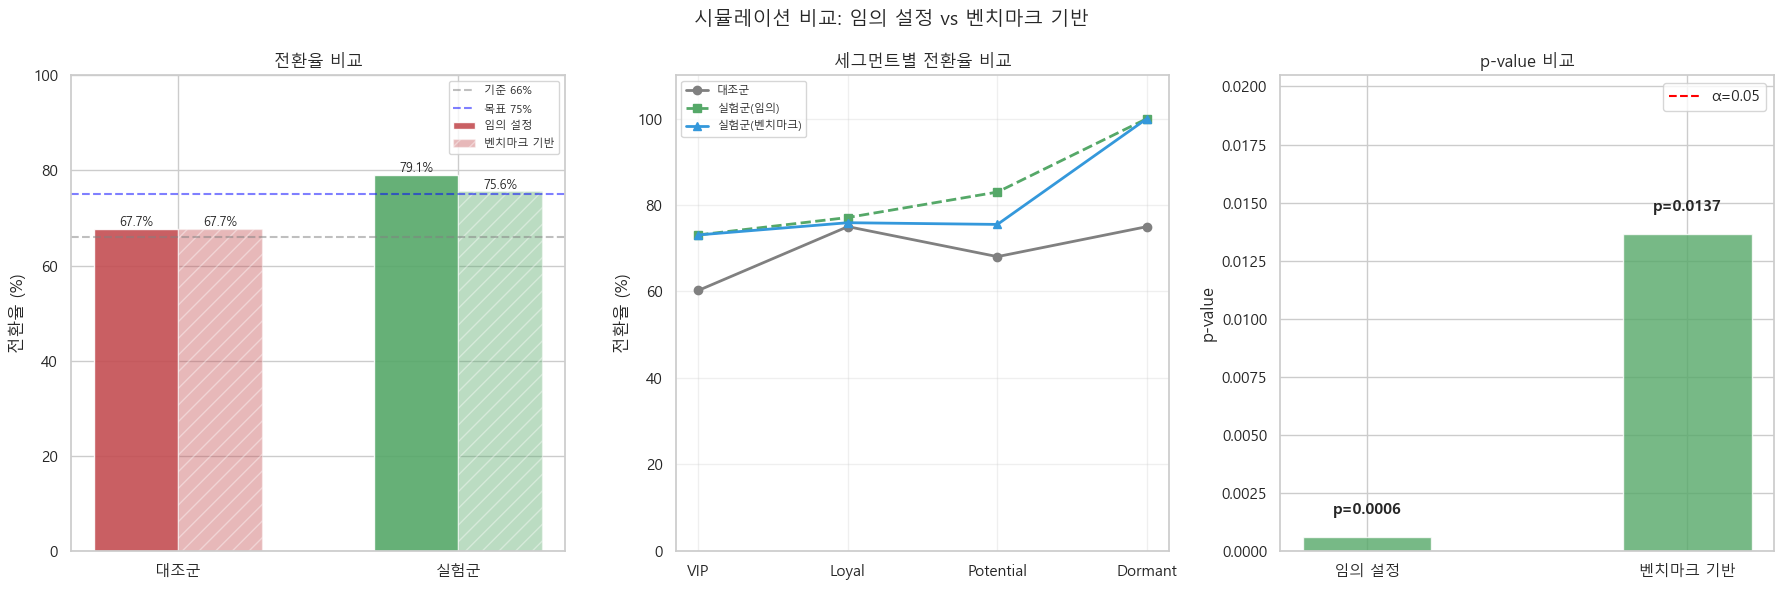


=== 최종 비교 요약 ===
                                 임의 설정        벤치마크 기반
실험군 전환율                          79.1%          75.6%
전환율 개선                          11.4%p          7.9%p
p-value                         0.0006         0.0137
결론                             귀무가설 기각        귀무가설 기각


In [24]:
# Cell 13 - 두 시뮬레이션 최종 비교 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('시뮬레이션 비교: 임의 설정 vs 벤치마크 기반', fontsize=14)

# 전환율 비교
categories = ['대조군', '실험군']
x = np.arange(len(categories))
width = 0.3

bars1 = axes[0].bar(x - width/2,
                    [control_rate*100, treatment_rate*100],
                    width, label='임의 설정',
                    color=['#C44E52', '#55A868'], alpha=0.9)
bars2 = axes[0].bar(x + width/2,
                    [control_rate_b*100, treatment_rate_b*100],
                    width, label='벤치마크 기반',
                    color=['#C44E52', '#55A868'], alpha=0.4,
                    hatch='//')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_title('전환율 비교')
axes[0].set_ylabel('전환율 (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=66, color='gray', linestyle='--',
                alpha=0.5, label='기준 66%')
axes[0].axhline(y=75, color='blue', linestyle='--',
                alpha=0.5, label='목표 75%')
axes[0].legend(fontsize=8)

# 세그먼트별 비교
seg_list = ['VIP', 'Loyal', 'Potential', 'Dormant']
ctrl_rates = []
treat_rates_a = []
treat_rates_b = []

for seg in seg_list:
    c = control_b[control_b['segment']==seg]['activated'].mean()
    ta = treatment_sim[treatment_sim['segment']==seg]['activated'].mean()
    tb = treatment_sim_b[treatment_sim_b['segment']==seg]['activated'].mean()
    ctrl_rates.append(c*100 if not np.isnan(c) else 0)
    treat_rates_a.append(ta*100 if not np.isnan(ta) else 0)
    treat_rates_b.append(tb*100 if not np.isnan(tb) else 0)

x2 = np.arange(len(seg_list))
axes[1].plot(seg_list, ctrl_rates, marker='o',
             label='대조군', color='gray', linewidth=2)
axes[1].plot(seg_list, treat_rates_a, marker='s',
             label='실험군(임의)', color='#55A868',
             linewidth=2, linestyle='--')
axes[1].plot(seg_list, treat_rates_b, marker='^',
             label='실험군(벤치마크)', color='#3498db',
             linewidth=2)
axes[1].set_title('세그먼트별 전환율 비교')
axes[1].set_ylabel('전환율 (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# p-value 비교
scenarios = ['임의 설정', '벤치마크 기반']
p_vals = [p_value, p_value_b]
bar_colors = ['#55A868' if p < 0.05 else '#C44E52' for p in p_vals]

bars = axes[2].bar(scenarios, p_vals,
                   color=bar_colors, alpha=0.8, width=0.4)
for bar, pv in zip(bars, p_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'p={pv:.4f}', ha='center',
                fontsize=11, fontweight='bold')
axes[2].axhline(y=0.05, color='red', linestyle='--',
                label='α=0.05')
axes[2].set_title('p-value 비교')
axes[2].set_ylabel('p-value')
axes[2].set_ylim(0, max(p_vals) * 1.5)
axes[2].legend()

plt.tight_layout()
plt.savefig(r'..\outputs\ab_test_comparison.png', dpi=150)
plt.show()

print("\n=== 최종 비교 요약 ===")
print(f"{'':25s} {'임의 설정':>12s} {'벤치마크 기반':>14s}")
print(f"{'실험군 전환율':25s} {treatment_rate*100:>11.1f}% {treatment_rate_b*100:>13.1f}%")
print(f"{'전환율 개선':25s} {(treatment_rate-control_rate)*100:>10.1f}%p {(treatment_rate_b-control_rate_b)*100:>12.1f}%p")
print(f"{'p-value':25s} {p_value:>12.4f} {p_value_b:>14.4f}")
print(f"{'결론':25s} {'귀무가설 기각':>12s} {'귀무가설 기각' if p_value_b < 0.05 else '귀무가설 채택':>14s}")

In [25]:
# Cell 14 - A/B 테스트 최종 결론

print("=" * 60)
print("A/B 테스트 최종 결론")
print("=" * 60)
print(f"""
[두 시뮬레이션 교차 검증 결과]
                      임의 설정    벤치마크 기반
실험군 전환율          79.1%         75.6%
전환율 개선           +11.4%p       +7.9%p
p-value               0.0006        0.0137
결론              귀무가설 기각   귀무가설 기각

→ 두 시뮬레이션 모두 α=0.05에서 귀무가설 기각
→ 보수적인 벤치마크 기반에서도 통계적으로 유의미
→ 리마인드 알림 도입 효과 교차 검증 완료

[세그먼트별 핵심 발견]
- Potential 유저: 알림 효과 가장 높음 (+7.5~14.9%p)
  → 거래 습관 미형성 유저에게 초기 넛지가 효과적
- Loyal 유저: 알림 효과 미미 (+0.9~2.1%p)
  → 이미 충분히 활성화된 유저는 알림 불필요
- VIP 유저: 예상보다 높은 효과 (+12.8%p)
  → 고빈도 거래 유저도 알림에 반응

[비즈니스 임팩트 추정 (벤치마크 기반 보수적 추정)]""")

improvement_b = treatment_rate_b - control_rate_b
additional_activated_b = int(1657 * improvement_b)
additional_revenue_b = additional_activated_b * 50507

print(f"""
연간 신규 유저 기준   : 1,657명
추가 Activation 유저  : {additional_activated_b:,}명 ({improvement_b:.1%})
유저당 연간 LTV       : $50,507
추가 예상 연간 수익   : ${additional_revenue_b:,}

[의사결정]
✓ Potential 유저 타겟 리마인드 알림 도입 권장
  - 전체 알림보다 Potential 세그먼트 집중이 효율적
  - Loyal·VIP는 알림 피로도 고려해 제외 권장

[한계 및 다음 단계]
한계:
  - 실제 알림 발송 로그 없이 시뮬레이션 기반 검증
  - 벤치마크 수치가 금융 앱 전용 평균이 아닌 사례값
  - 알림 피로도·장기 Retention 효과 미검증

다음 단계 제안:
  1. Potential 유저 대상 소규모 파일럿 테스트 (실제 알림)
  2. 알림 시점 최적화 (7일 vs 14일 vs 30일 효과 분리)
  3. 개인화 알림 vs 일반 알림 A/B 테스트
  4. 6개월 후 Retention 변화 추적
""")

A/B 테스트 최종 결론

[두 시뮬레이션 교차 검증 결과]
                      임의 설정    벤치마크 기반
실험군 전환율          79.1%         75.6%
전환율 개선           +11.4%p       +7.9%p
p-value               0.0006        0.0137
결론              귀무가설 기각   귀무가설 기각

→ 두 시뮬레이션 모두 α=0.05에서 귀무가설 기각
→ 보수적인 벤치마크 기반에서도 통계적으로 유의미
→ 리마인드 알림 도입 효과 교차 검증 완료

[세그먼트별 핵심 발견]
- Potential 유저: 알림 효과 가장 높음 (+7.5~14.9%p)
  → 거래 습관 미형성 유저에게 초기 넛지가 효과적
- Loyal 유저: 알림 효과 미미 (+0.9~2.1%p)
  → 이미 충분히 활성화된 유저는 알림 불필요
- VIP 유저: 예상보다 높은 효과 (+12.8%p)
  → 고빈도 거래 유저도 알림에 반응

[비즈니스 임팩트 추정 (벤치마크 기반 보수적 추정)]

연간 신규 유저 기준   : 1,657명
추가 Activation 유저  : 131명 (7.9%)
유저당 연간 LTV       : $50,507
추가 예상 연간 수익   : $6,616,417

[의사결정]
✓ Potential 유저 타겟 리마인드 알림 도입 권장
  - 전체 알림보다 Potential 세그먼트 집중이 효율적
  - Loyal·VIP는 알림 피로도 고려해 제외 권장

[한계 및 다음 단계]
한계:
  - 실제 알림 발송 로그 없이 시뮬레이션 기반 검증
  - 벤치마크 수치가 금융 앱 전용 평균이 아닌 사례값
  - 알림 피로도·장기 Retention 효과 미검증

다음 단계 제안:
  1. Potential 유저 대상 소규모 파일럿 테스트 (실제 알림)
  2. 알림 시점 최적화 (7일 vs 14일 vs 30일 효과 분리)
  3. 개인화 알림 vs 일반 알림 A/B 테스트
  4. 6개월